<a href="https://colab.research.google.com/github/maschu09/mless/blob/main/remote_sensing/Random_forest_classifier_on_remote_sensing_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random forest classifier for landcover classification from remote sensing images

In this tasks, we will use a portion of the [SAT-6](https://csc.lsu.edu/~saikat/deepsat/) dataset from Louisiana State University and NASA Ames Research Center.

For this demonstration, we only use the test dataset, which consists of 81000 samples randomly distributed across 6 landcover classes.

In [1]:
# Random forest classifier for landcover classification
# Author: Ankit Patnala, JSC, 2025; updated by Martin Schultz, April 2026
# Download necessary packages if right kernel is not present
# Not needed in colab
#!pip install pandas
#!pip install scikit-learn
#!pip install matplotlib

In [2]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

## Obtaining the data
The data is available via this B2share link [link](https://b2share.eudat.eu/records/89654eac10724d30a6c7e51f2c5422de). Download all the files at the same folder path where you are creating this notebook

Alternatively use the following wget commands to download the data

The following cell can be executed in Google colab

In [13]:
# load the csv file with the image data. Each row belongs to one sample. Each sample has 3136 columns i.e. 4 channels (R,G,B, and NIR) and 28 \times 28 spatial size
landcover_df = pd.read_csv("./data/X_test_sat6.csv",header=None)
landcover_df

,0,1,2,3,4,5,6,7,8,9,...,3126,3127,3128,3129,3130,3131,3132,3133,3134,3135
0,95,91,61,157,105,113,101,179,50,35,...,107,181,118,137,127,205,90,105,86,183
1,102,102,103,137,108,110,116,154,88,83,...,91,157,95,92,84,143,89,85,76,130
2,47,54,95,10,79,89,108,15,96,131,...,118,17,82,98,125,18,61,69,113,13
3,200,181,178,218,192,177,176,214,162,141,...,139,203,157,138,125,193,147,128,107,187
4,85,101,100,15,87,102,97,16,54,71,...,74,8,37,49,76,6,27,43,69,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80995,82,82,115,17,104,123,131,23,100,119,...,146,32,137,152,159,44,159,166,166,61
80996,170,148,147,174,203,188,163,190,211,197,...,134,172,163,154,136,175,172,157,143,177
80997,140,136,126,190,156,163,152,208,152,170,...,126,162,93,111,119,170,68,66,61,123
80998,89,87,99,13,64,66,89,9,16,26,...,111,15,49,52,97,11,47,56,102,9


&#x1F479;  _Task:_ Make sure you understand this data structure.

&#x1F479;  _Question:_ What would you need to do to extract only the green and the infrared channel from this data?

In [7]:
# Read the annotation file to get the annotation i.e. classname corresponding to the labels
annotations = pd.read_csv("./data/sat6annotations.csv", header=None)
print(annotations)
labels = annotations[0].values
print(f'class labels: {labels}')

             0  1  2  3  4  5  6
0     building  1  0  0  0  0  0
1  barren_land  0  1  0  0  0  0
2        trees  0  0  1  0  0  0
3    grassland  0  0  0  1  0  0
4         road  0  0  0  0  1  0
5        water  0  0  0  0  0  1
class labels: <StringArray>
['building', 'barren_land', 'trees', 'grassland', 'road', 'water']
Length: 6, dtype: str


In [21]:
labels

<StringArray>
['building', 'barren_land', 'trees', 'grassland', 'road', 'water']
Length: 6, dtype: str

The data structure that you see above is called _one-hot encoding_

&#x1F479; _Question:_ What is the advantage of this encoding compared to a simple class label like '0', '1', '2', '3', '4', '5', or text labels like 'building', 'barren_land', ...?

In [26]:
# load the csv file with the labels of all samples
labels_df = pd.read_csv("./data/y_test_sat6.csv",header=None)
print(labels_df)
# get the names of the class labels (here, only "0" to "5")
# These correspond to the labels printed above
column_names = labels_df.columns.values

       0  1  2  3  4  5
0      0  0  1  0  0  0
1      0  0  1  0  0  0
2      0  0  0  0  0  1
3      0  1  0  0  0  0
4      0  0  0  0  0  1
...   .. .. .. .. .. ..
80995  0  0  0  0  0  1
80996  0  1  0  0  0  0
80997  0  0  1  0  0  0
80998  0  0  0  0  0  1
80999  0  0  1  0  0  0

[81000 rows x 6 columns]


# Plot random samples for illustration

&#x1F479; _Task:_ Make sure you understand the following code for creating balanced samples from the overall dataset and the reshaping of ther data that is needed for plotting.

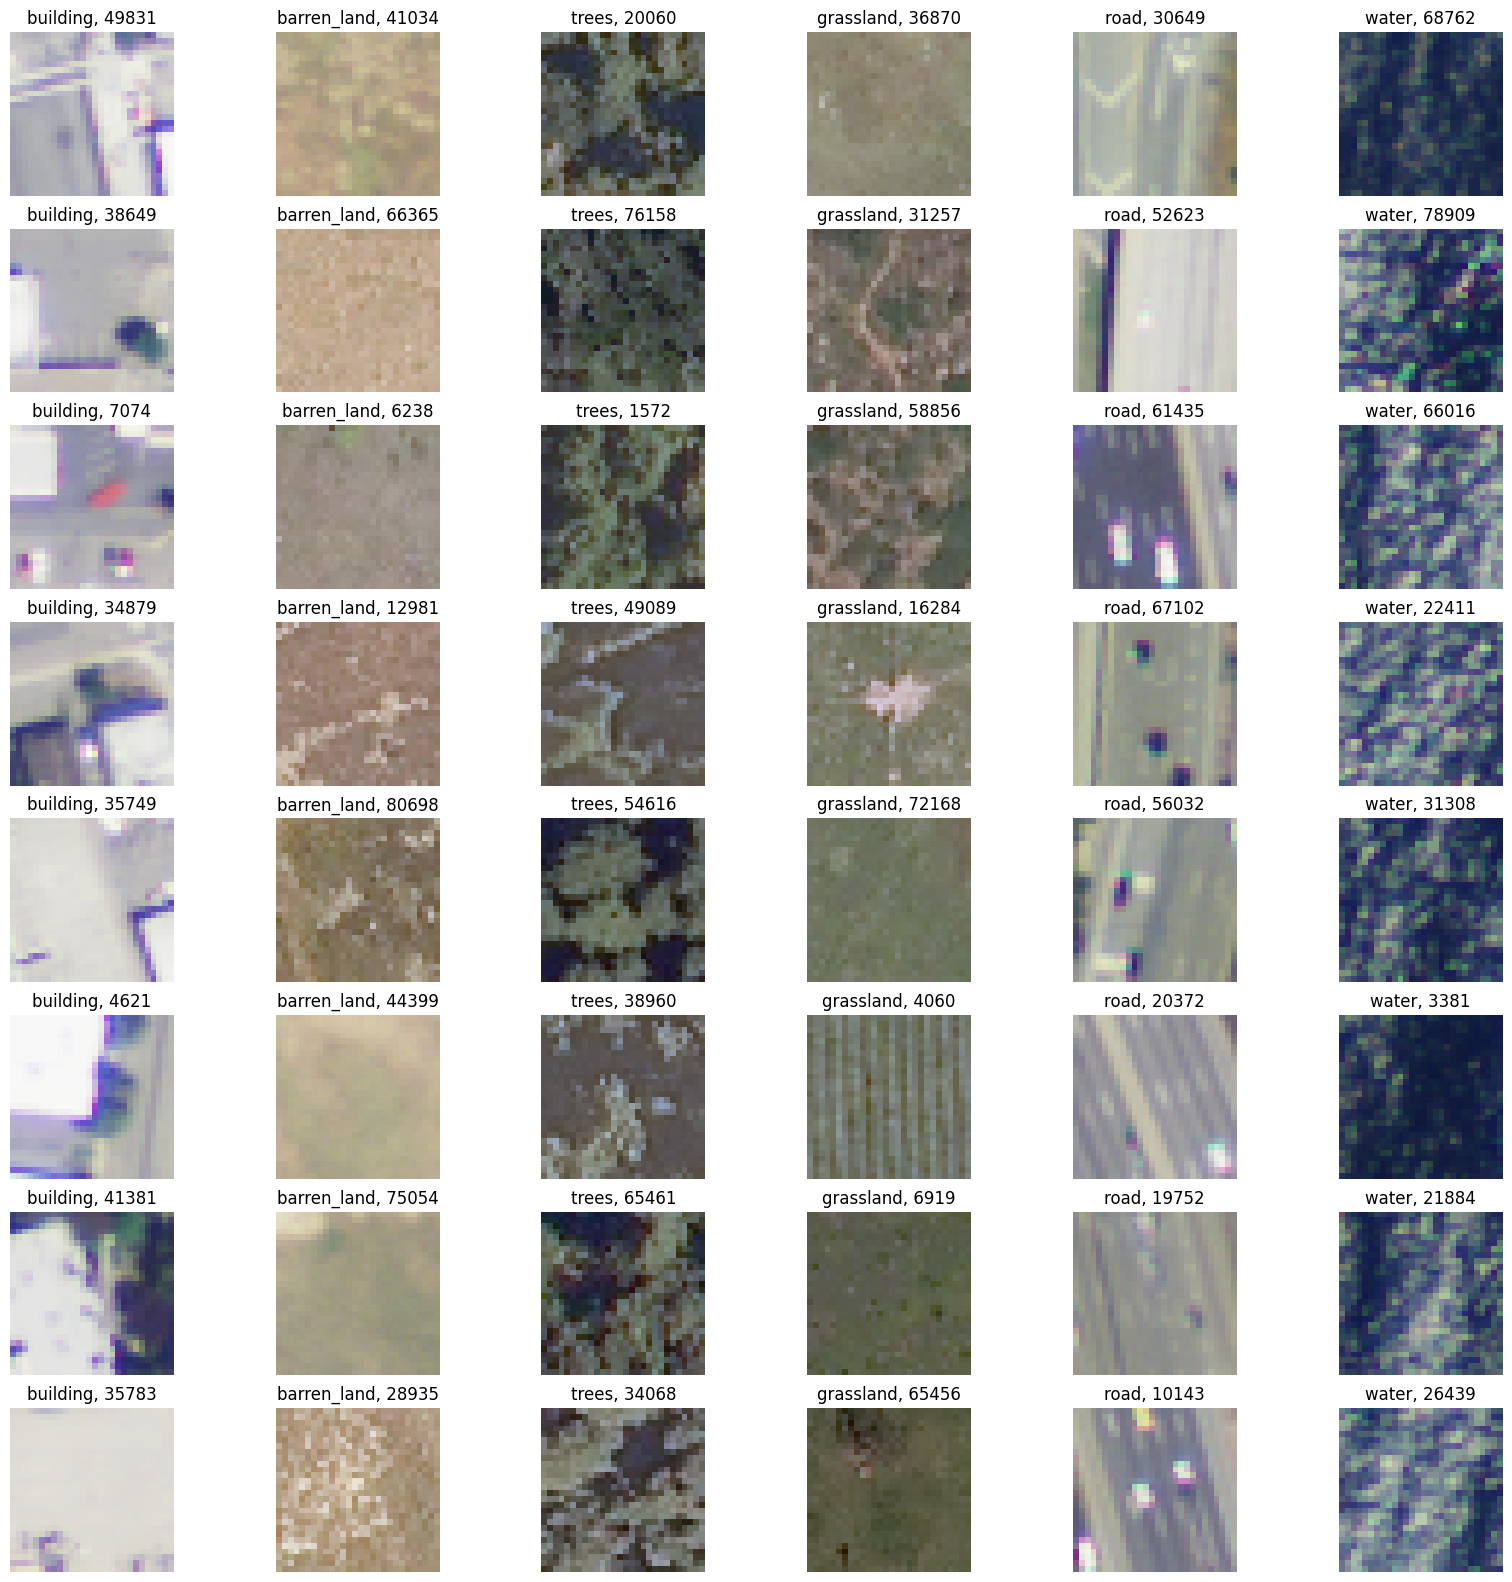

In [9]:
num_classes = len(column_names)
num_samples = 8  # number of rows to plot
sample_idx = []
for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_samples from this index list - make sure to avoid duplicates
    sample_idx.append(np.random.choice(np.where(class_idx.values)[0], size=num_samples, replace=False).tolist())

fig, ax = plt.subplots(num_samples, num_classes, figsize=(20,20))
for i in range(num_samples):
    for j in range(num_classes):
        data_index = sample_idx[j][i]
        ax[i,j].set_title(f"{labels[j]}, {data_index}")
        ax[i,j].axis('off')
        data = np.reshape(landcover_df.iloc[data_index].values,(-1,28,28,4))
        ax[i,j].imshow(data[0,...,:3])

plt.show()

### Create the training and test datasets

Collect equal number of samples from each class for training and testing, respectively

In [10]:
num_train = 1000
num_test = 100
train_idx = []
test_idx = []
for column in column_names:
    # find all indices of a given class
    class_idx = labels_df[column] == 1
    # randomly select num_train and num_test values from this index list - make sure to avoid duplicates
    train_idx.extend(np.random.choice(np.where(class_idx.values)[0], size=num_train, replace=False).tolist())
    test_idx.extend(np.random.choice(np.where(class_idx.values)[0], size=num_test, replace=False).tolist())
print(f'number of train indices: {len(train_idx)}, number of test indices: {len(test_idx)}')


number of train indices: 6000, number of test indices: 600


&#x1F479;  _Question:_ Why use `extend`here and `append` above?

&#x1F479;  _Question:_ What is wrong with the above code?

In [11]:
# Shuffle train and test indices
train_idx = np.random.permutation(train_idx)
test_idx = np.random.permutation(test_idx)
# Extract images and labels corresponding to the selected indices
train_X = landcover_df.iloc[train_idx]
train_y = labels_df.iloc[train_idx]
test_X = landcover_df.iloc[test_idx]
test_y = labels_df.iloc[test_idx]

In [28]:
from sklearn.model_selection import train_test_split

num_train = 1000
num_test = 100
train_idx = []
test_idx = []

data_train, data_test, labels_train, labels_test = train_test_split(\
            data, \
            labels_df, \
            test_size=0.20, \
            random_state=42)

ValueError: Found input variables with inconsistent numbers of samples: [1, 81000]

&#x1F479; _Question:_ Why do you want to shuffle the samples in the train and test datasets?

In [ ]:
train_X

## Define and intialize random classifier from scikit-learn

In [ ]:
rf = RandomForestClassifier(n_estimators=100)

## Train the random forest

In [ ]:
from datetime import datetime, timedelta

In [ ]:
t0 = datetime.now()
rf.fit( train_X, train_y)
t1 = datetime.now()

In [ ]:
t1 - t0

## Check the prediction on the test set

In [ ]:
rf.score(test_X, test_y)

&#x1F479;  _Task:_ Add code to plot a couple of successes and failures (i.e., where predicted labels agree/disagree with the given labels in test_y)